In [1]:
import ptime

from lasy.laser import Laser
from lasy.profiles.gaussian_profile import GaussianProfile
from lasy.optical_elements import Axiparabola

import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c

import full_field

In [2]:
l_w = 10.54e-7
f0 = 7e-2
delta = 2e-2
w = 1e-3
tau = 1.5e-14
E = 6.2
w0 = f0 * l_w / w / np.pi
zr = np.pi * w**2 / l_w
print(zr)
vf = 1.0005*c
print(w/w0)
npoints = (8000, 2000)
print(npoints)
ptime.ptime()

2.9806381912616633
42.580545589452335
(8000, 2000)
runtime: 5 s 794 ms


In [3]:
profile = GaussianProfile(l_w, (1,0), E, w, tau, 0.0)
laser = Laser("rt", (0, -10*tau), (12*w, 6*tau), npoints, profile)
ptime.ptime()

runtime: 8 s 444 ms


runtime: 12 s 729 ms


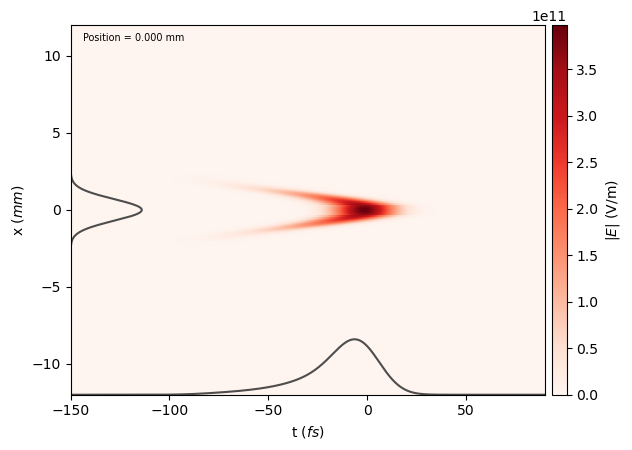

In [4]:
axiparabola = Axiparabola(f0, delta, w)
import radialGroupDelay as RGD
def tau_D(r):
    return RGD.tau_D_const_v(r, vf, axiparabola)
radial_delay = RGD.RadialGroupDelay(tau_D, l_w)
laser.apply_optics(radial_delay)
laser.show()
ptime.ptime()

Extracting full field
dt = 3.00037504688086e-17


  0%|          | 00:00<? [?it/s]

Displaying


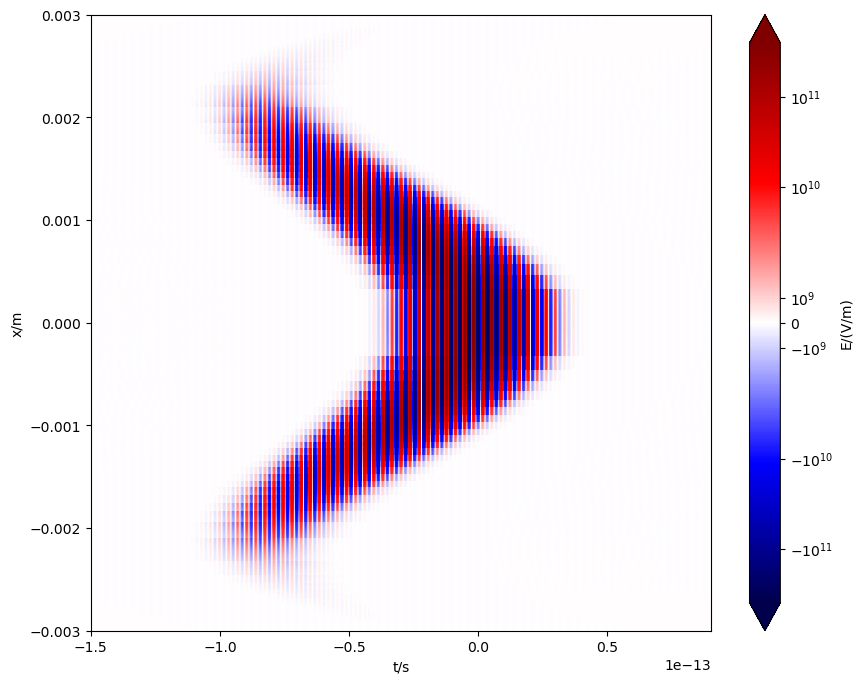

In [5]:
full_field.show_field(laser, Nr=2000, Nt=8000)

In [ ]:
N = 14
M = 5

zs = np.zeros(M+1)
rs = np.zeros(N)
taus = np.zeros(N)
dts = np.zeros((M+1,N))


for n in range(N):
    print(n, "should be", tau_D(n*(2*w/(N-2))), "; is", full_field.get_tpeak(laser, nr=int(2*n*(npoints[0]/6/(N-2)))))
    rs[n] = n*(2*w/(N-2))
    taus[n] = tau_D(n*(2*w/(N-2)))
    dts[0, n] = full_field.get_tpeak(laser, nr=int(2*n*(npoints[0]/6/(N-2))))
for m in range(M):
    print("Step", m+1, "of", M, ":")
    zs[m+1] = (m+1)*zr/M
    print("z=", zs[m+1])
    laser.propagate(zr/M)
    laser.show()
    for n in range(N):
        print(n*(2*w/(N-2)), "should be", tau_D(n*(2*w/(N-2))), "; is", full_field.get_tpeak(laser, nr=int(2*n*(npoints[0]/12/(N-2)))))
        dts[m+1, n] = full_field.get_tpeak(laser, nr=int(2*n*(npoints[0]/12/(N-2))))
    
    ptime.ptime()

0 should be 0.0 ; is 2.311531072000642e-31
1 should be -9.239379812814388e-16 ; is -5.2736483450830334e-15
2 should be -3.664204527233338e-15 ; is -1.5820945035249094e-14
3 should be -8.126157444178442e-15 ; is -2.988400728880387e-14
4 should be -1.4152059742654665e-14 ; is -4.746283510574731e-14
5 should be -2.152107963741508e-14 ; is -6.504166292269075e-14
6 should be -2.9949290547427926e-14 ; is -7.910472517624551e-14
7 should be -3.90896710958766e-14 ; is -7.910472517624551e-14
8 should be -4.85321051101597e-14 ; is -6.504166292269078e-14
9 should be -5.780338162189093e-14 ; is -2.2852476162026477e-14
10 should be -6.636719486689919e-14 ; is 5.0978578108213684e-14
11 should be -7.362414428522854e-14 ; is -7.312119576905227e-14
12 should be -7.89117345211382e-14 ; is -1.1390219919926244e-13
13 should be -8.150437542310261e-14 ; is -7.997261918011382e-14
Step 1 of 5 :
z= 0.5961276382523326
Available backends are: NP
NP is chosen


  0%|          | 00:00<? [?it/s]

0.0 should be 0.0 ; is -6.237900171203345e-15
0.00016666666666666666 should be -9.239379812814388e-16 ; is -5.1957948373982846e-15
0.0003333333333333333 should be -3.664204527233338e-15 ; is -6.84517391976994e-15
0.0005 should be -8.126157444178442e-15 ; is -1.0491610803726792e-14
0.0006666666666666666 should be -1.4152059742654665e-14 ; is -1.4480747099361455e-14
0.0008333333333333333 should be -2.152107963741508e-14 ; is -1.8565579521002444e-14
0.001 should be -2.9949290547427926e-14 ; is -2.2820318587127548e-14
0.0011666666666666665 should be -3.90896710958766e-14 ; is -2.713286989604201e-14
0.0013333333333333333 should be -4.85321051101597e-14 ; is -3.090911685099298e-14
0.0015 should be -5.780338162189093e-14 ; is -3.4531978328142884e-14
0.0016666666666666666 should be -6.636719486689919e-14 ; is -3.932340548673225e-14
0.0018333333333333333 should be -7.362414428522854e-14 ; is -4.3857283162400036e-14
0.002 should be -7.89117345211382e-14 ; is -4.689625494863419e-14
0.002166666666

  0%|          | 00:00<? [?it/s]

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(np.concatenate((taus[:0:-1], taus))*1e15, np.concatenate((-rs[:0:-1], rs)), label="$\\tau_D(r)$")
for m in range(M+1):
    ax.plot(np.concatenate((dts[m,:0:-1], dts[m,:]))*1e15, np.concatenate((-rs[:0:-1], rs)), ".", label="$\\Delta t$ at $z="+str(zs[m]/zr)[:5]+"z_R$")
ax.set_xlabel("$\\Delta t$/fs")
ax.set_ylabel("$r$/m")
ax.legend()
plt.show()

In [ ]:
ptime.ptime()